In [3]:
# 导包
import pandas as pd
import seaborn as sns               # 底层依赖 Matplotlib 
import matplotlib.pyplot as plt
import os

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

os.chdir(r'C:/my_code/learning-notes/2.Data_Analysis')

# 1. 扩展_Pandas绘图

In [4]:
# 介绍: Pandas绘图可以基于 df对象直接绘图, 它的底层依赖 Matplotlib

In [5]:
# 1.机器学习概述. 加载数据集, 并设置 第1列为 索引列.
df = pd.read_csv('./data/winemag-data_first150k.csv', index_col=0)
df

,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude
...,...,...,...,...,...,...,...,...,...,...
150925,Italy,Many people feel Fiano represents southern Ita...,NaN,91,20.0,Southern Italy,Fiano di Avellino,NaN,White Blend,Feudi di San Gregorio
150926,France,"Offers an intriguing nose with ginger, lime an...",Cuvée Prestige,91,27.0,Champagne,Champagne,NaN,Champagne Blend,H.Germain
150927,Italy,This classic example comes from a cru vineyard...,Terre di Dora,91,20.0,Southern Italy,Fiano di Avellino,NaN,White Blend,Terredora
150928,France,"A perfect salmon shade, with scents of peaches...",Grand Brut Rosé,90,52.0,Champagne,Champagne,NaN,Champagne Blend,Gosset


In [6]:
# 2. 查看数据集.
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 150930 entries, 0 to 150929
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   country      150925 non-null  str    
 1   description  150930 non-null  str    
 2   designation  105195 non-null  str    
 3   points       150930 non-null  int64  
 4   price        137235 non-null  float64
 5   province     150925 non-null  str    
 6   region_1     125870 non-null  str    
 7   region_2     60953 non-null   str    
 8   variety      150930 non-null  str    
 9   winery       150930 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 11.5 MB


Index(['country', 'description', 'designation', 'points', 'price', 'province',
       'region_1', 'region_2', 'variety', 'winery'],
      dtype='str')

- 需求1: 绘制图形, 展示 产葡萄酒最多的10个产地的信息.

In [7]:
# 3. 分组统计
# 思路1: 根据产地(province)分组, 基于points列(也可以是其它的不包含缺失值的列) 进行count统计即可.
df.groupby('province', as_index=False).points.count().sort_values('points', ascending=False).head(10)

# 思路2: value_counts() 值的个数, 且会自动降序排列, 它相当于: groupby() + count() + sort_values()
df['province'].value_counts().head(10)

province
California          44508
Washington           9750
Tuscany              7281
Bordeaux             6111
Northern Spain       4892
Mendoza Province     4742
Oregon               4589
Burgundy             4308
Piedmont             4093
Veneto               3962
Name: count, dtype: int64

<Axes: xlabel='province'>

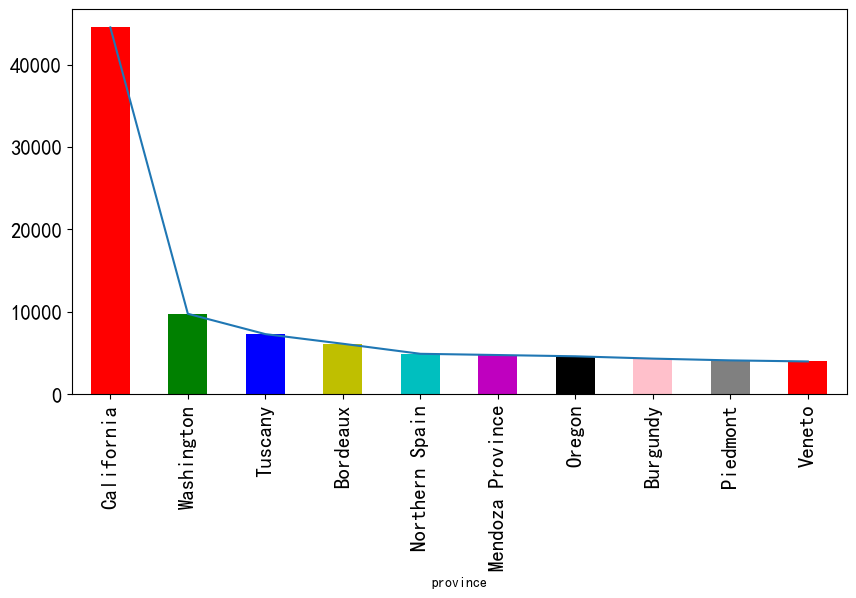

In [8]:
# 4. 针对于上述的结果, 绘图展示. 
df['province'].value_counts().head(10).plot()          # 折线图, 语法糖

# df['province'].value_counts().head(10).plot.line(figsize=(10, 5), color=['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'gray'])          # 折线图
df['province'].value_counts().head(10).plot.bar(figsize=(10, 5), color=['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'gray'], fontsize=15)      # 柱状图

<Axes: xlabel='province'>

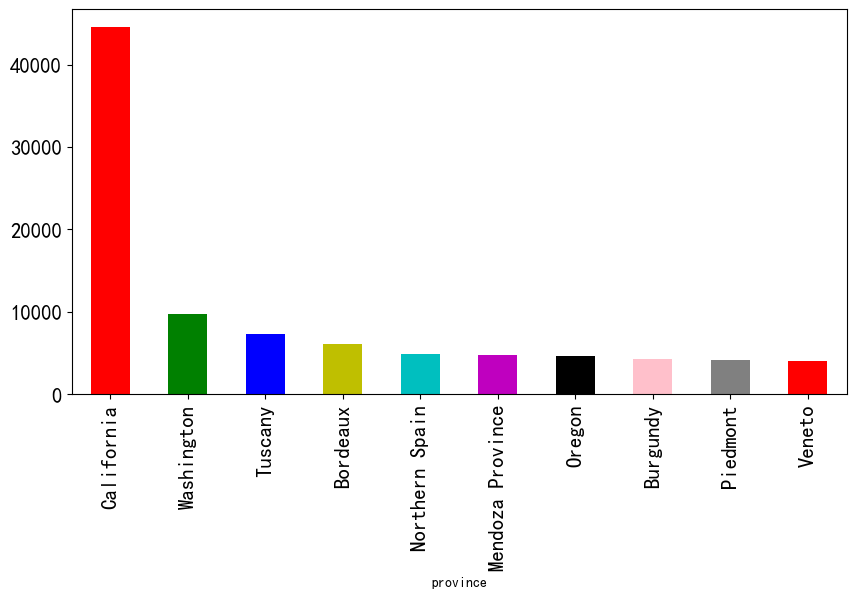

In [9]:
# 5. 最终写法.
# step1: 定义变量, 记录参数, 字典形式.
text_kwargs = dict(figsize=(10, 5), color=['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'gray'], fontsize=15)
# print(text_kwargs)

# step2: 绘图, 传参.
df['province'].value_counts().head(10).plot.bar(**text_kwargs)

- 需求2: 绘制图形, 展示 葡萄酒最多的10个产地的 占比

<Axes: xlabel='province'>

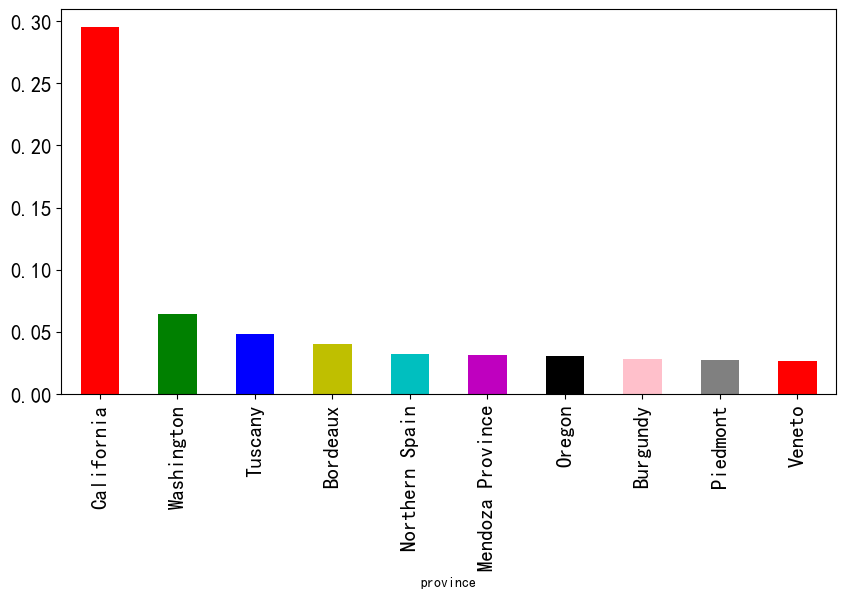

In [10]:
# 1.机器学习概述. 计算 葡萄酒最多的10个产地.
df['province'].value_counts().head(10)

# 2. 计算 每个产地的 占比, 即:  产地产的葡萄酒数量 / 总共的葡萄酒数量
# len(df)     # 150930
df['province'].value_counts().head(10) / len(df)

# 3. 绘图
(df['province'].value_counts().head(10) / len(df)).plot.bar(**text_kwargs)

- 需求3: 展示 每个评分的葡萄酒种类(个数), 即: 80分 -> 多少种酒, 85分 -> 多少种酒, 90分 -> 多少种酒, 95分 -> 多少种酒, 100分 -> 多少种酒

<Axes: xlabel='points'>

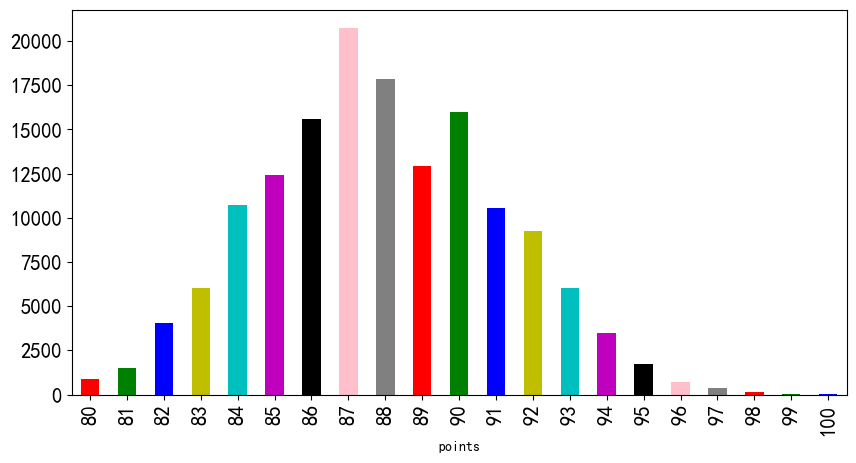

In [11]:
# df.points.value_counts().sort_index().plot.line(**text_kwargs)      # 折线图
# df.points.value_counts().sort_index().plot.area(**text_kwargs)      # 面积图, 就是把区域内进行填充
df.points.value_counts().sort_index().plot.bar(**text_kwargs)         # 柱状图, 就是把区域内进行填充

# 2. 扩展_Seaborn绘图

In [12]:
# 介绍: Seaborn 是一个 Python 数据可视化库, 它基于 Matplotlib, 并且它提供了更高级的绘图功能.
# Pandas中绘图直接写单词, 例如: hist(), Seaborn中绘图是 图形名 + plot(), 例如: histplot()

In [14]:
# 1.机器学习概述. 加载数据集.
df = pd.read_csv('./data/tips.csv')     # 离线方式.
#df = sns.load_dataset('tips')             # 在线方式(电脑要联网), tips是Seaborn自带的数据集
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


- 需求1: 绘制图形, 展示 男女总账单的情况

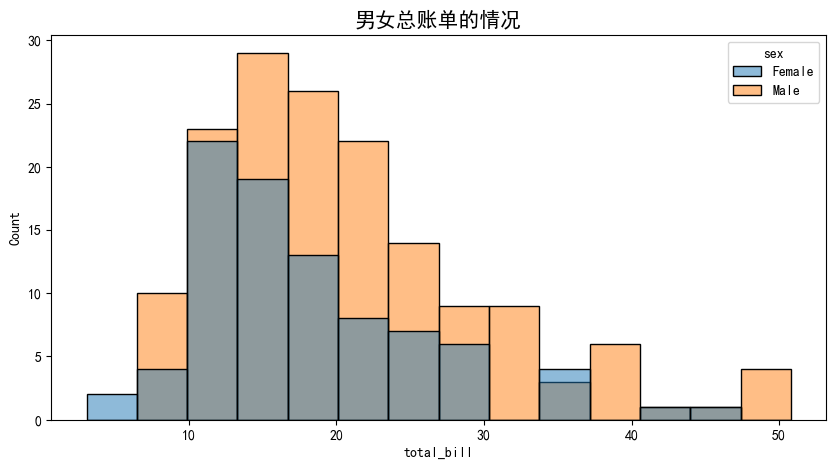

In [15]:
# 1.机器学习概述. 创建画布
fig, ax = plt.subplots(figsize=(10, 5))
# 2. 绘制图形.
# 参1: data: 数据集
# 参2: x: x轴的列名
# 参3: hue: 分组依据的列名
sns.histplot(data=df, x='total_bill', hue='sex')

# 3. 添加标题.
ax.set_title('男女总账单的情况', fontsize=15)

# 4. 展示图形.
plt.show()

- 散点图, scatter(), regplot(), jointplot()

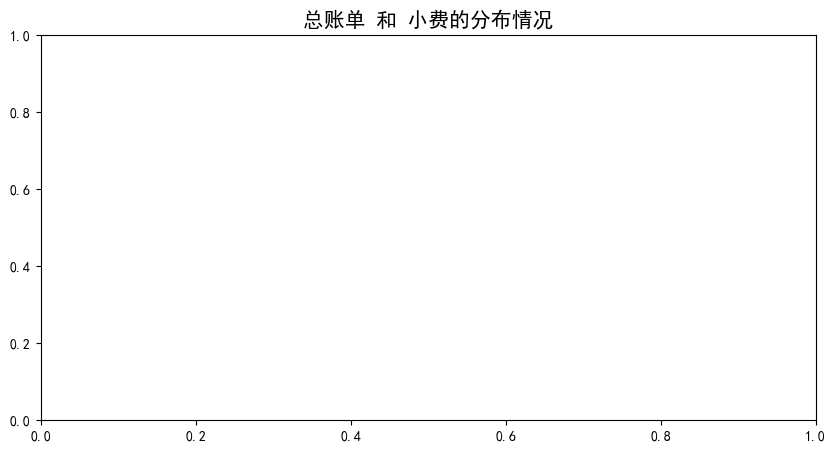

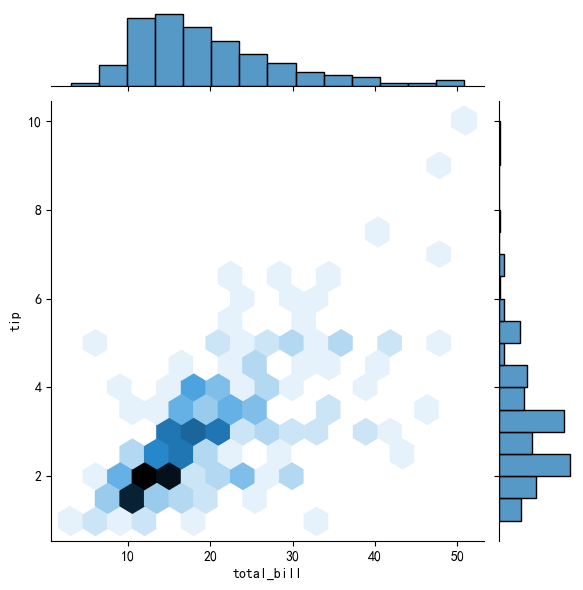

In [16]:
# 需求: 描述 总账单 和 小费的分布情况
# 1.机器学习概述. 创建画布
fig, ax = plt.subplots(figsize=(10, 5))

# 2. 绘制散点图
# 思路1: 散点图, scatter()
# 参1: data: 数据集
# 参2: x: x轴的列名, 总账单
# 参3: y: y轴的列名, 小费
# sns.scatterplot(data=df, x='total_bill', y='tip')

# 思路2: regplot(), 可以绘制散点图, 且可以绘制 拟合回归线(底层是: 线性回归)
# sns.regplot(data=df, x='total_bill', y='tip')
# sns.regplot(data=df, x='total_bill', y='tip', fit_reg=True) # 绘制拟合回归线
# sns.regplot(data=df, x='total_bill', y='tip', fit_reg=False)  # 不绘制拟合回归线

# 思路3: jointplot(), 可以绘制散点图, 且可以绘制 拟合回归线(底层是: 线性回归)
sns.jointplot(data=df, x='total_bill', y='tip', kind='hex')     # kind=hex -> 蜂巢图

# 3. 添加标题.
ax.set_title('总账单 和 小费的分布情况', fontsize=15)
# 4. 展示图形.
plt.show()

- 箱线图, boxplot(), violinplot()

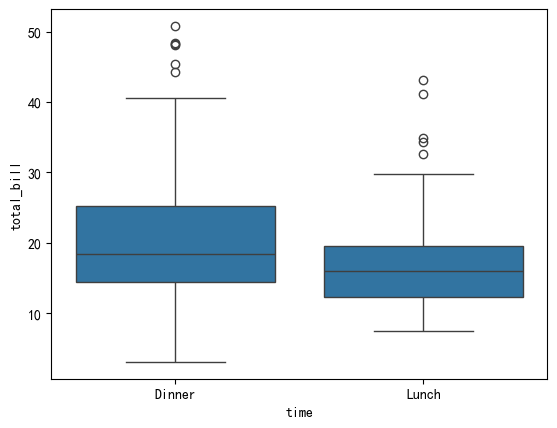

In [17]:
# 绘制箱线图(也叫: 盒须图), 展示: 时间(time) 和 账单总金额(total_bill) 的分布情况
sns.boxplot(data=df, x='time', y='total_bill')
plt.show()

In [ ]:
# 需求: 查看 性别(sex) 和 账单总金额(total_bill), 时间(time) 的分布情况
# 小提琴图, 适用于: 箱线图 + 密度图
# 参1: data: 数据集
# 参2: x: x轴的列名, 时间(time)
# 参3: y: y轴的列名, 账单总金额(total_bill)
# 参4: hue: 分组依据的列名, 性别(sex)
# 参5: split: 是否将箱线图进行分割, 默认为False, 即不进行分割
sns.violinplot(data=df, x='time', y='total_bill', hue='sex', split=True)
plt.show()